In [74]:
import numpy as np
import imageio
from skimage.color import rgb2gray
from skimage.feature import SIFT, match_descriptors
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import matplotlib as mpl
from matplotlib import pyplot as plt
from glob import glob
import zipfile

In [ ]:
# Database images of digital children's books
with zipfile.ZipFile("Childrens-Books.zip", "r") as zip_ref:
    zip_ref.extractall("Childrens-Books")

# Images of physical children's books who have a ditigal version in the database
with zipfile.ZipFile("extra-queries.zip", "r") as zip_ref:
    zip_ref.extractall("extra-queries")

# Images of physical children's books who do not have a digital version in the database
with zipfile.ZipFile("queries.zip", "r") as zip_ref:
    zip_ref.extractall("queries")

In [76]:
def load_images_from_folder(folder):
    files = sorted(glob(f"{folder}/*.jpg"))
    images = [imageio.imread(filename) for filename in files]
    return images

In [77]:
Childrens_Books_images = load_images_from_folder("Childrens-Books/Childrens-Books")
extra_queries_images = load_images_from_folder("extra-queries/extra-queries")
queries_images = load_images_from_folder("queries/queries")

C:\Users\rafis\AppData\Local\Temp\ipykernel_23160\3925300340.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(filename) for filename in files]


In [78]:
Childrens_Books_greys = [rgb2gray(image) for image in Childrens_Books_images]
extra_queries_greys = [rgb2gray(image) for image in extra_queries_images]
queries_greys = [rgb2gray(image) for image in queries_images]

In [79]:
def describe_images(images):
    #extract a list of SIFT descriptors
    descriptors_list = []
    sift = SIFT()
    for image in images:
        sift.detect_and_extract(image)
        descriptors_list.append(sift.descriptors)
    return descriptors_list

In [80]:
descriptors_database = describe_images(Childrens_Books_greys)
descriptors_queries = describe_images(queries_greys)
descriptors_extra_queries = describe_images(extra_queries_greys)



In [81]:
kmeans = KMeans(n_clusters=1000)
kmeans.fit(np.vstack(descriptors_database))
def document_images(descriptors_list):
    labels = [kmeans.predict(descriptors) for descriptors in descriptors_list]
    documents = [" ".join(str(label) for label in image_labels)
                 for image_labels in labels]
    return documents

In [82]:
database_documents = document_images(descriptors_database)
queries_documents = document_images(descriptors_queries)
extra_queries_documents = document_images(descriptors_extra_queries)

In [86]:
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
database_histogram = vectorizer.fit_transform(database_documents)
queries_histogram = vectorizer.transform(queries_documents)
extra_queries_histogram = vectorizer.transform(extra_queries_documents)

nnmodel = NearestNeighbors(n_neighbors=5, metric="cosine")
nnmodel.fit(database_histogram)
neigh_ind = nnmodel.kneighbors(queries_histogram, return_distance=False)
extra_neigh_ind = nnmodel.kneighbors(extra_queries_histogram, return_distance=False)

In [84]:
def display_neighbors(n_ind, queries_images):
    for i, neighbors in enumerate(n_ind):
        plt.figure(figsize=(15, 5))
        plt.subplot(1, len(neighbors) + 1, 1)
        plt.imshow(queries_images[i])
        plt.title("Query")
        plt.axis("off")
        for j, neighbor in enumerate(neighbors):
            plt.subplot(1, len(neighbors) + 1, j + 2)
            plt.imshow(Childrens_Books_images[neighbor])
            plt.title(f"Neighbor {j + 1}")
            plt.axis("off")
        plt.show()

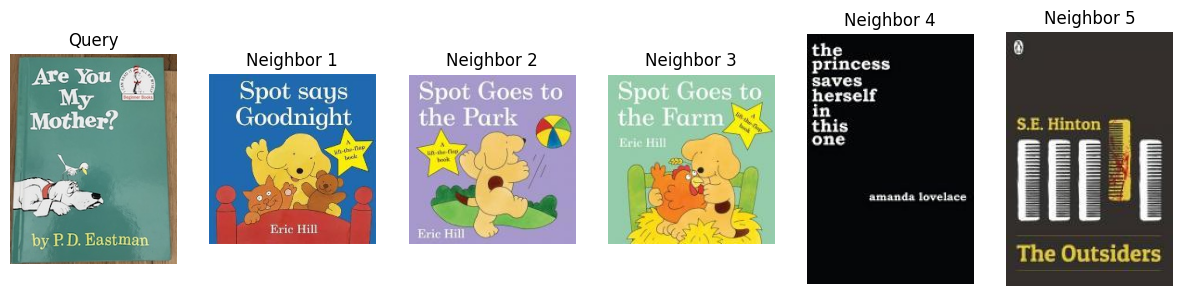

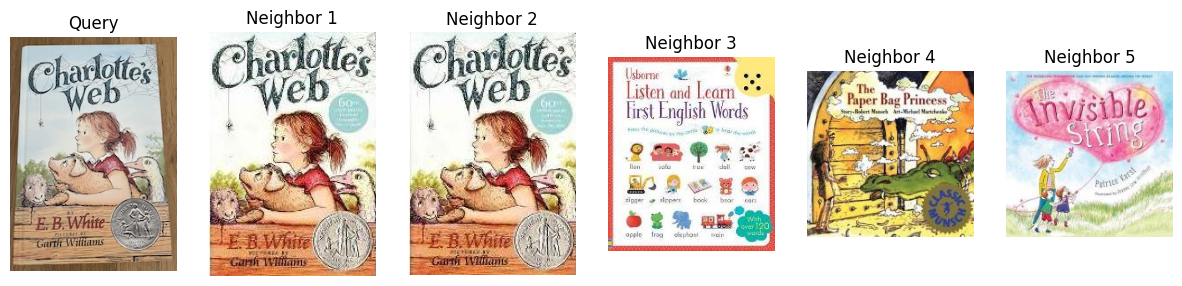

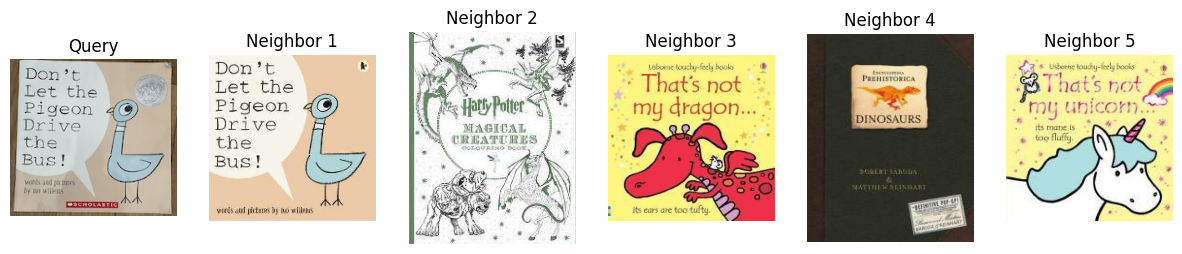

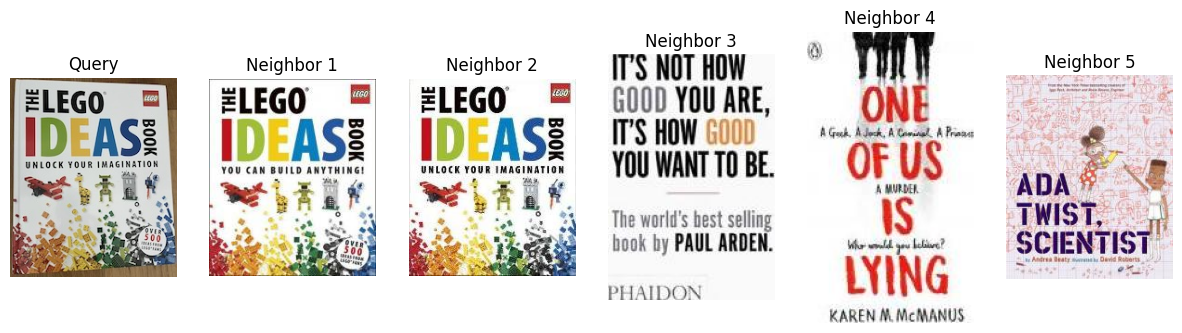

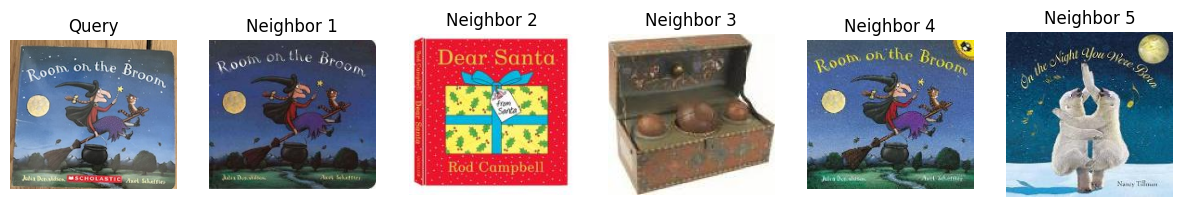

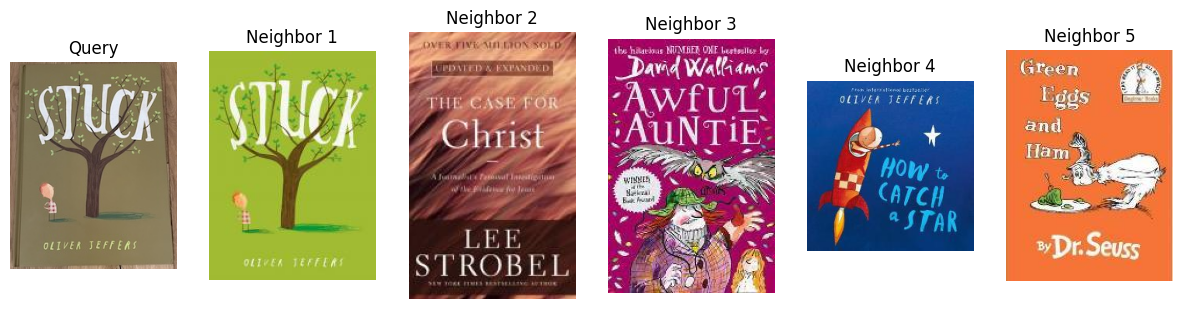

In [85]:
display_neighbors(neigh_ind, queries_images)

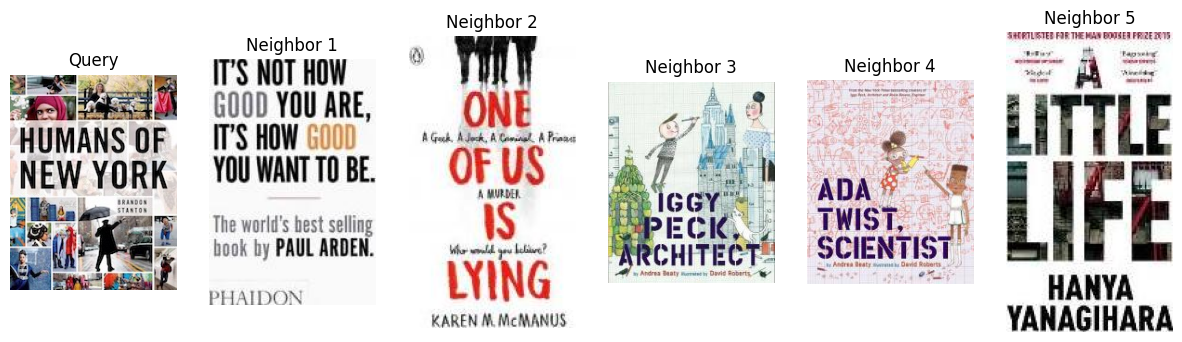

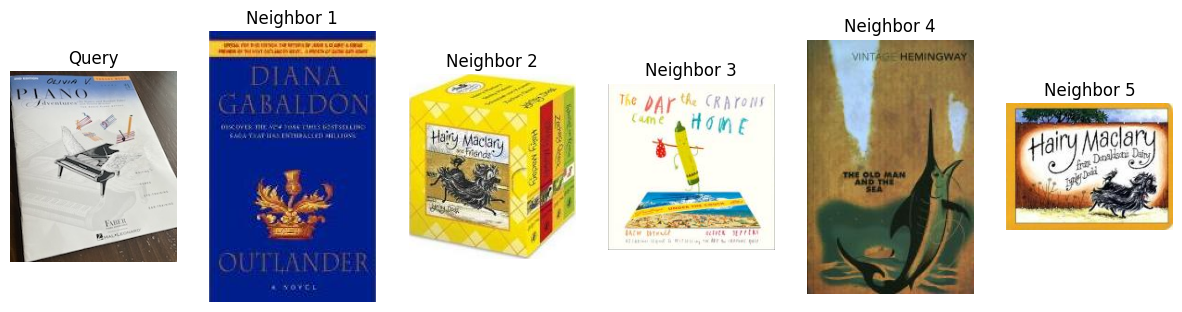

In [87]:
display_neighbors(extra_neigh_ind, extra_queries_images)